In [7]:
import json, random
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

jsonl_path = "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train_uni_8.jsonl"
jsonl_path = "/glob/g01-cache/pf/Yushuo/vjepa201/data/embodiedscan_train.jsonl"
rows = [json.loads(l) for l in open(jsonl_path)]
print(f"Total rows: {len(rows)}")

Total rows: 96764


## random select an item to illustrate

Query: facing the front of the dresser , select the lamp that is to the left of it
Images: 8
Boxes: [None, [0.0, 61.12792226714443, 102.13766843940732, 210.11442807577305], None, [0.0, 0.0, 2.438155751521876, 111.67722163703598], None, None, None, [51.18260616595708, 0.0, 156.91869180105823, 113.40378470219444]]


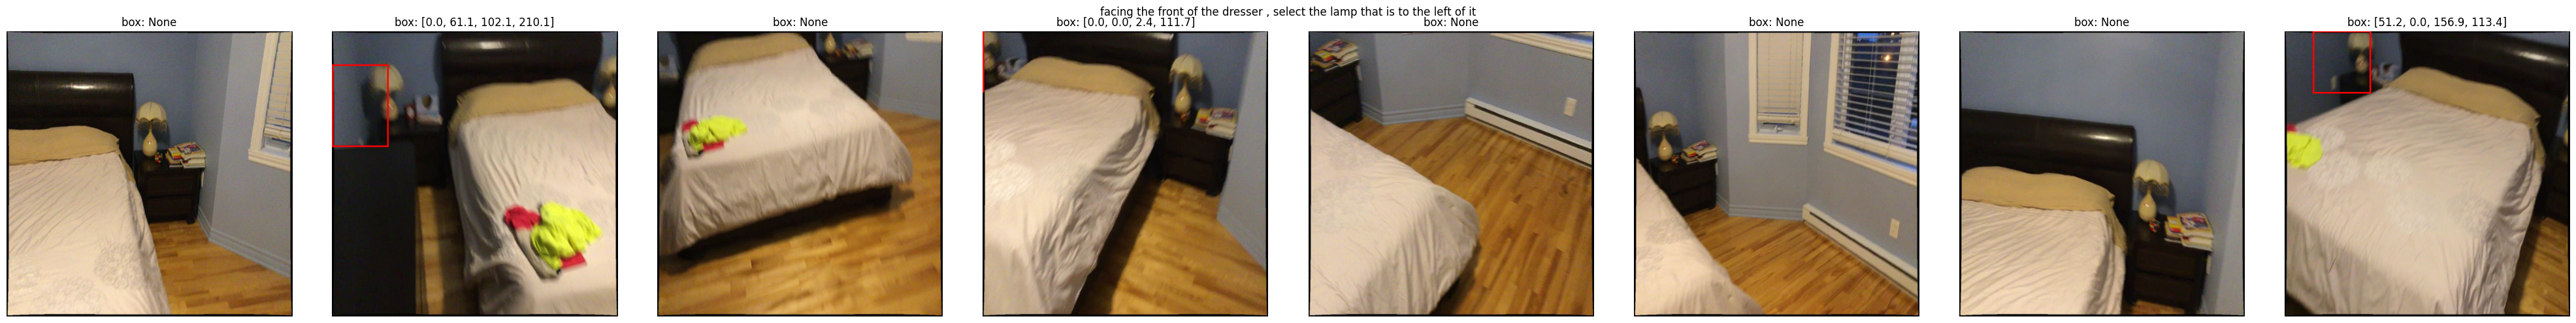

In [8]:
row = random.choice(rows)
print("Query:", row["query"])
print("Images:", len(row["images"]))
print("Boxes:", row["boxes"])

fig, axes = plt.subplots(1, len(row["images"]), figsize=(5*len(row["images"]), 5))
if len(row["images"]) == 1:
      axes = [axes]

for ax, img_path, box in zip(axes, row["images"], row["boxes"]):
      img = Image.open(img_path).convert("RGB")
      img = img.resize((518, 518))
      draw = ImageDraw.Draw(img)
      if box is not None:
          x1, y1, x2, y2 = box
          draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
      ax.imshow(img)
      ax.set_title("box: " + (str([round(v,1) for v in box]) if box else "None"))
      ax.axis("off")

plt.suptitle(row["query"], fontsize=12)
plt.tight_layout()
plt.show()

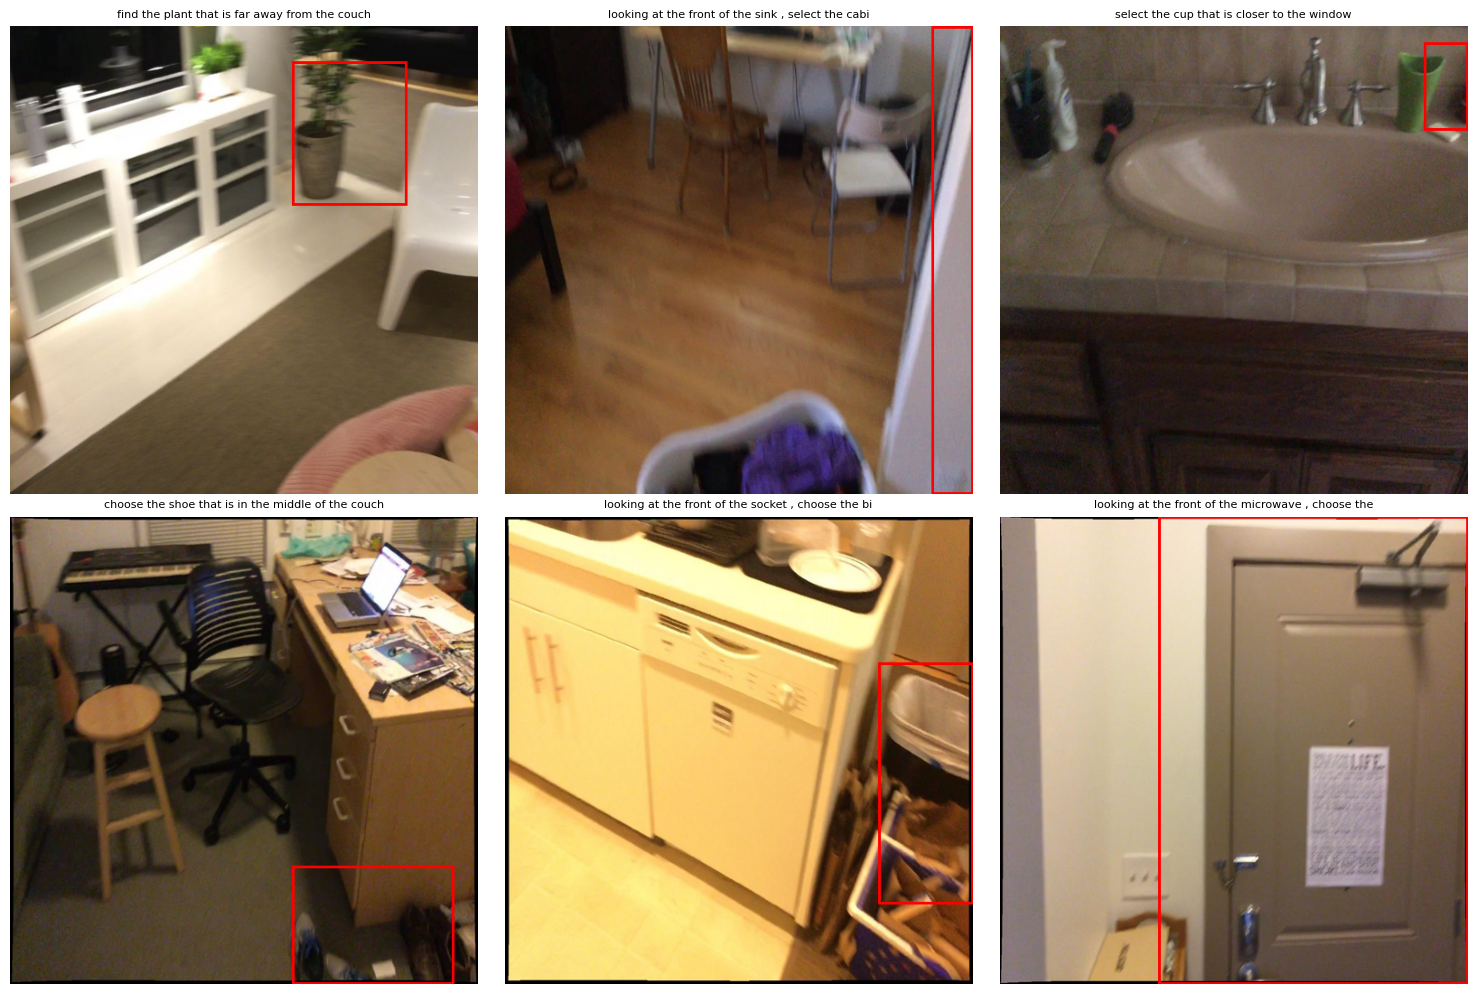

In [3]:
samples = random.sample(rows, 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, row in zip(axes.flat, samples):
      for img_path, box in zip(row["images"], row["boxes"]):
          if box is not None:
              img = Image.open(img_path).convert("RGB").resize((518, 518))
              draw = ImageDraw.Draw(img)
              draw.rectangle(box, outline="red", width=3)
              ax.imshow(img)
              ax.set_title(row["query"][:50], fontsize=8)
              ax.axis("off")
              break

plt.tight_layout()
plt.show()

In [4]:
## check if there is some 2d boxes
import json
entries =json.load(open('/glob/g01-cache/pf/Yushuo/vjepa201/source_data/embodiedscan/embodiedscan/embodiedscan_train_vg.json'))
print(entries[0].keys())
print(entries[0])

dict_keys(['scan_id', 'target_id', 'distractor_ids', 'text', 'target', 'anchors', 'anchor_ids', 'tokens_positive'])
{'scan_id': 'scannet/scene0191_00', 'target_id': 5, 'distractor_ids': [6], 'text': 'the board that is beside the door', 'target': 'board', 'anchors': ['door'], 'anchor_ids': [3], 'tokens_positive': [[4, 9]]}


## SPAR-7M jsonl Examination

### Load

In [9]:
import json, random, os
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

SPAR_JSON = "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/qa_jsonl/scannet_3229k.json"
SPAR_IMG_ROOT = "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/images"
SPAR_JSONL_ROOT = "/glob/g01-cache/pf/Yushuo/vjepa201/source_data/spar/scannet/qa_jsonl"

config = json.load(open(SPAR_JSON))
print(f"Total task types: {len(config)}\n")
print(f"{'Task type':<50} {'#samples':>10}")
print("-" * 62)
for k, v in config.items():
    print(f"{k:<50} {v['length']:>10,}")


Total task types: 50

Task type                                            #samples
--------------------------------------------------------------
obj_spatial_relation_oo_sentence                      116,634
depth_prediction_oc_sentence                          105,066
depth_prediction_oc_fill                              105,066
depth_prediction_oc_select                            105,066
depth_prediction_oo_sentence                           76,837
depth_prediction_oo_fill                               76,837
depth_prediction_oo_select                             66,556
distance_prediction_oc_sentence                       102,526
distance_prediction_oc_fill                           102,526
distance_prediction_oc_select                         102,526
distance_prediction_oo_sentence                        92,742
distance_prediction_oo_fill                            92,742
distance_prediction_oo_select                          92,639
distance_infer_center_oc_sentence              

Task type : distance_prediction_oo
ID        : scene0631_01_29
Q: How far, measured in meters, is the center of book (red point) from the center of shelf (blue point) in the image? Calculate or judge based on the 3D center points of these objects. Answer using a single number and nothing else.
A: 0.9
Images    : ['scene0631_01/image_color/360.jpg']


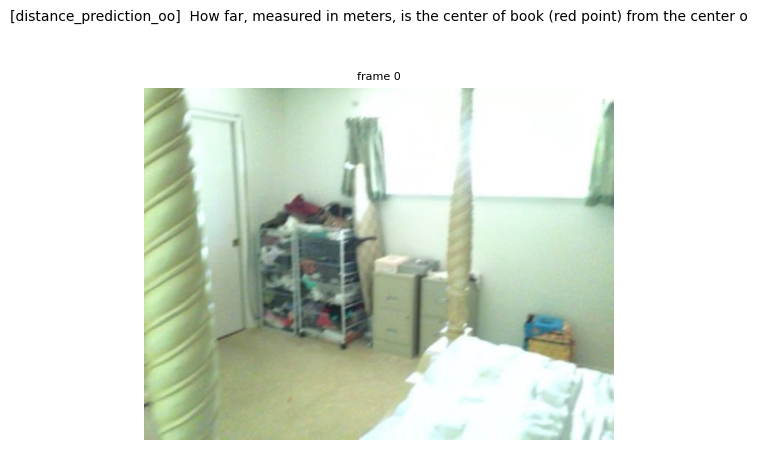

In [10]:
def draw_point(img, xy, color, radius=10):
    draw = ImageDraw.Draw(img)
    x, y = xy
    draw.ellipse([x - radius, y - radius, x + radius, y + radius],
                 fill=color, outline="white", width=2)
    return img

# pick a random task type and load one item from its first jsonl shard
task_name = random.choice(list(config.keys()))
jsonl_rel = config[task_name]["annotation"]   # e.g. "../datasets/scannet_processed/..."
# remap the annotation path to the actual local path
jsonl_filename = os.path.basename(jsonl_rel)
task_subdir    = "/".join(jsonl_rel.split("/")[-4:-1])   # e.g. "train/distance_prediction_oo_mv/sentence"
jsonl_path     = os.path.join(SPAR_JSONL_ROOT, task_subdir, jsonl_filename)

rows = [json.loads(l) for l in open(jsonl_path)]
row  = random.choice(rows)

print(f"Task type : {row['type']}")
print(f"ID        : {row['id']}")
print(f"Q: {row['conversations'][0]['value']}")
print(f"A: {row['conversations'][1]['value']}")
print(f"Images    : {row['image']}")

# determine which frames carry the annotated points (if any)
red_pts   = row.get("red_point",    [])
blue_pts  = row.get("blue_point",   [])
pt_idx    = row.get("point_img_idx", [])  # [[red_img_idx, blue_img_idx], ...]

images_to_show = row["image"][:8]   # cap at 8 for readability
n = len(images_to_show)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
if n == 1:
    axes = [axes]

for i, (ax, rel_path) in enumerate(zip(axes, images_to_show)):
    full_path = os.path.join(SPAR_IMG_ROOT, rel_path)
    img = Image.open(full_path).convert("RGB")

    # overlay colored dots
    for pair_idx, (rp, bp, pidx) in enumerate(zip(red_pts, blue_pts, pt_idx)):
        r_img_i, b_img_i = pidx
        if i == r_img_i:
            draw_point(img, rp, "red")
        if i == b_img_i:
            draw_point(img, bp, "blue")

    ax.imshow(img)
    ax.set_title(f"frame {i}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"[{row['type']}]  {row['conversations'][0]['value'][:80]}", fontsize=10)
plt.tight_layout()
plt.show()


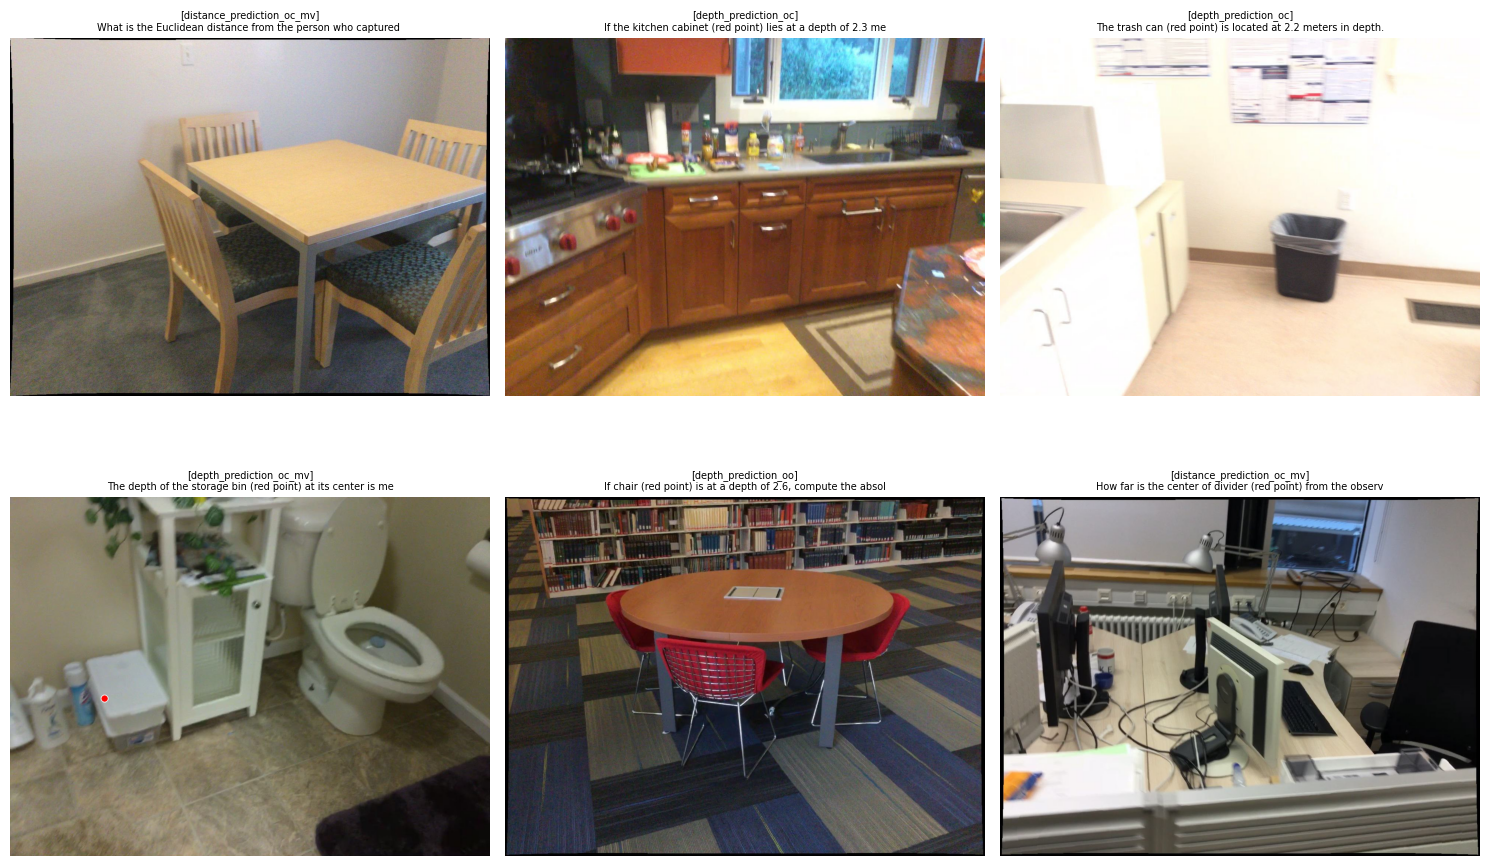

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax in axes.flat:
    task_name = random.choice(list(config.keys()))
    jsonl_rel = config[task_name]["annotation"]
    jsonl_filename = os.path.basename(jsonl_rel)
    task_subdir    = "/".join(jsonl_rel.split("/")[-4:-1])
    jsonl_path     = os.path.join(SPAR_JSONL_ROOT, task_subdir, jsonl_filename)

    rows = [json.loads(l) for l in open(jsonl_path)]
    row  = random.choice(rows)

    red_pts  = row.get("red_point",    [])
    blue_pts = row.get("blue_point",   [])
    pt_idx   = row.get("point_img_idx", [])

    # show the first image that carries an annotated point, or just frame 0
    shown = False
    for pair_idx, (rp, bp, pidx) in enumerate(zip(red_pts, blue_pts, pt_idx)):
        r_i, b_i = pidx
        img_i = r_i  # show the red-point frame
        img = Image.open(os.path.join(SPAR_IMG_ROOT, row["image"][img_i])).convert("RGB")
        draw_point(img, rp, "red")
        draw_point(img, bp, "blue") if b_i == r_i else None
        ax.imshow(img)
        shown = True
        break

    if not shown:
        img = Image.open(os.path.join(SPAR_IMG_ROOT, row["image"][0])).convert("RGB")
        ax.imshow(img)

    ax.set_title(f"[{row['type'][:30]}]\n{row['conversations'][0]['value'][:60]}", fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()
